In [19]:
import concurrent.futures
import time
import glob

from scipy import ndimage
from scipy.optimize import curve_fit

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvo
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import shutil

In [20]:
def spectrum(ra_target, dec_target, folder, aper=False):
    allfiles = glob.glob(f'{folder}/*.fits')
    ww, ff, ee = [], [], []
    for a in allfiles:
        hdulist = fits.open(a)
        img = hdulist[1].data
        wave = hdulist[6].data
        err = np.sqrt(hdulist[3].data)
        spectral_image_header = hdulist[1].header
        wcs = WCS(spectral_image_header)
        ra, dec = wcs.wcs.crval
        x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
        spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")
    
        spectral_wcs.sip = None
        wl, bw = spectral_wcs.pixel_to_world(x, y)
        spectral_image = hdulist["IMAGE"]
        spectral_image_data = spectral_image.data
        (y, x) = np.indices(spectral_image.shape)
        spectral_coords = spectral_wcs.pixel_to_world(x, y)
        wavelength, bandwidth = spectral_coords
    
        coord = SkyCoord(ra=ra_target*u.deg, dec=dec_target*u.deg, frame="icrs")
        
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        try: 
            flux = img[int(y+0.5),p1:p2]
            ferr = err[int(y+0.5),p1:p2]
            if aper:
                flux = np.mean(img[int(y+0.5)-2:int(y+0.5)+3, p1:p2], axis=0)
            lam = wavelength.value[int(y+0.5),int(x+0.5)]
            print(y, x, lam)
            sm = 2
            flux = ndimage.gaussian_filter1d(flux, sm)
            ferr = ndimage.gaussian_filter1d(ferr, sm) / np.sqrt(2*np.sqrt(np.pi)*sm)
            if aper: ff.append(np.mean(flux[78:83]))
            else: ff.append(flux[80]); ee.append(ferr[80])
            ww.append(lam)
        except: 
            shutil.move(a, 'useless/'+a.split('/')[1])
            continue
    ww, ff, ee = np.array(ww), np.array(ff), np.array(ee)
    ww, ff, ee = np.sort(ww), ff[np.argsort(ww)], ee[np.argsort(ww)]
    mask = np.isnan(ff)
    return ww[~mask], ff[~mask], ee[~mask]

In [180]:
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C

In [149]:
import warnings
from matplotlib import rcParams
# Ignore all warnings
warnings.filterwarnings('ignore')
rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
    'font.size': 14
})

## CrA-151 - prestellar

In [194]:
rlist = [287.5857417, 287.5857417-0.017, 287.5857417+0.0153]
dlist = [-37.1408333, -37.1408333, -37.1408333, -37.1408333]

w1, f1, e1 = spectrum(287.5857417, -37.1408333, 'CrA-151-SPHEREx')
w2, f2, e2 = spectrum(287.5857417-0.017, -37.1408333, 'CrA-151-SPHEREx')
#w3, f3, e3 = spectrum(287.5857417+0.015, -37.1408333, 'CrA-151-SPHEREx')

w3, f3, e3 = spectrum(287.5857417-0.045, -37.1408333, 'CrA-151-SPHEREx')
#w5, f5, e5 = spectrum(287.5857417+0.018*2, -37.1408333, 'CrA-151-SPHEREx')

#w4, f4 = spectrum(287.5857417, -37.1208333, 'CrA-151-SPHEREx')
#w5, f5 = spectrum(287.5857417, -37.1608333, 'CrA-151-SPHEREx')
#w4, f4 = spectrum(287.5857417+0.16/2, -37.1408333, 'CrA-151-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
656.5532325833715 83

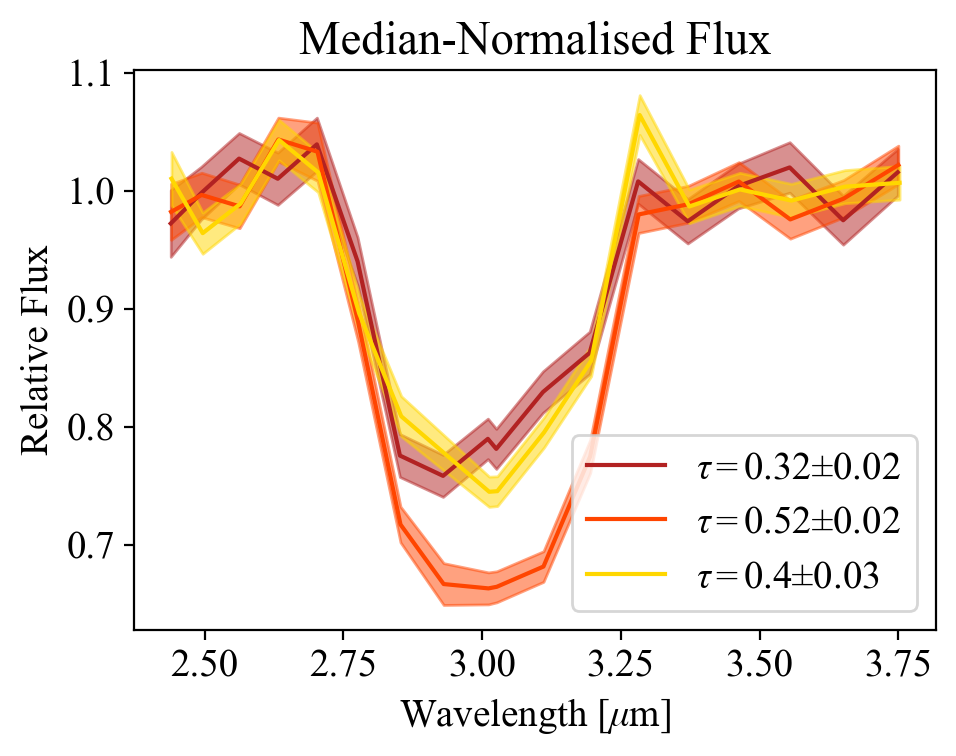

In [199]:
f1[10] = f2[10] = f3[10] = np.nan
f3[7] = np.nan
#f4[8] = f4[7] = f4[9] = np.nan


collist = ['firebrick', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/CrA-151-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

tau =  0.13809737880588455
tau =  0.22048352133369165
tau =  0.20024261269967508
tau =  0.16558209158570888
tau =  0.1583048174975298


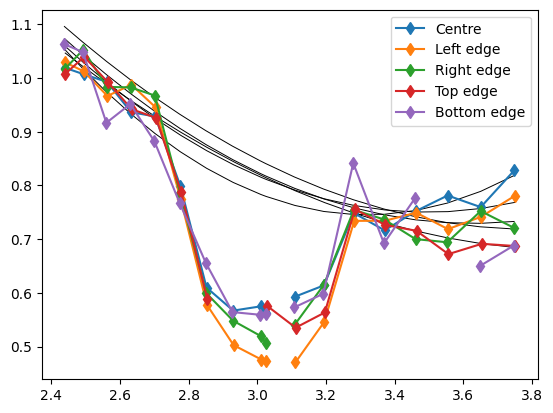

In [1434]:
f1[10] = f2[10] = f3[10] = f5[10] = np.nan
f4[8] = f4[7] = f4[9] = np.nan
f5[-3] = np.nan

for ww, ff, ee in zip([w1, w2, w3, w4, w5], [f1, f2, f3, f4, f5], [e1, e2, e3, e4, e5]):
    mask = np.isnan(ff)
    ww, ff, ee = ww[~mask], ff[~mask], ee[~mask]

for ww, ff in zip([w1, w2, w3, w4, w5], [f1, f2, f3, f4, f5]):
    wv, fv = ww.copy(), ff.copy()
    mask = np.where(((wv <= 2.7) | (wv >= 3.3)) & ~np.isnan(fv))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[:5]), color='k', lw=0.7)
    print('tau = ',-np.log10(np.nanmin(fv) / cont_fit(wv[np.nanargmin(fv)],*popt)))

plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='', label='Centre')
plt.plot(w2, f2/np.nanmedian(f2[:4]), marker='', label='Left edge')
plt.plot(w3, f3/np.nanmedian(f3[:4]), marker='', label='Right edge')
plt.plot(w4, f4/np.nanmedian(f4[:4]), marker='d', label='Top edge')
plt.plot(w5, f5/np.nanmedian(f5[:4]), marker='d', label='Bottom edge')
plt.legend()

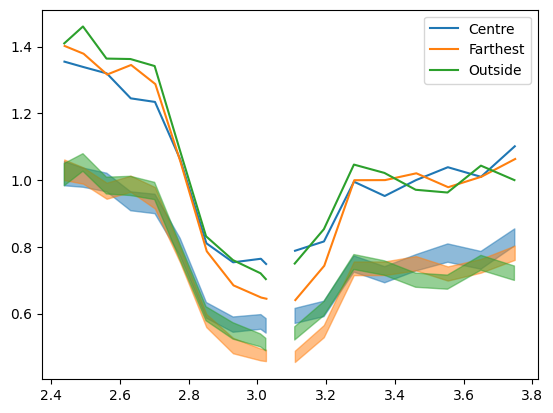

In [1436]:
plt.plot(w1, f1/np.nanmedian(f1[-7:]), marker='', label='Centre')
plt.fill_between(w1, (f1-e1)/np.nanmedian(f1[:4]), (f1+e1)/np.nanmedian(f1[:4]), color='C0', alpha=0.5)
plt.plot(w2, f2/np.nanmedian(f2[-7:]), marker='', label='Farthest')
plt.fill_between(w2, (f2-e2)/np.nanmedian(f2[:4]), (f2+e2)/np.nanmedian(f2[:4]), color='C1', alpha=0.5)
plt.plot(w3, f3/np.nanmedian(f3[-7:]), marker='', label='Outside')
plt.fill_between(w3, (f3-e3)/np.nanmedian(f3[:4]), (f3+e3)/np.nanmedian(f3[:4]), color='C2', alpha=0.5)
plt.legend()

## L1544 - prestellar:

In [ ]:
rlist = [76.0617917, 76.0337917, 76.0137917]
dlist = [25.18725, 25.22725, 25.25525]

In [147]:
# Background stars
rlist = [76.0657917, 76.0905000, 76.0920417]
dlist = [25.1992500, 25.2023889, 25.1605000]

# Emission
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]

w1, f1, e1 = spectrum(rlist[0], dlist[0], 'L1544-SPHEREx', aper=False)
w2, f2, e2 = spectrum(rlist[1], dlist[1], 'L1544-SPHEREx', aper=False)
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'L1544-SPHEREx', aper=False)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1106.5908925829663 8

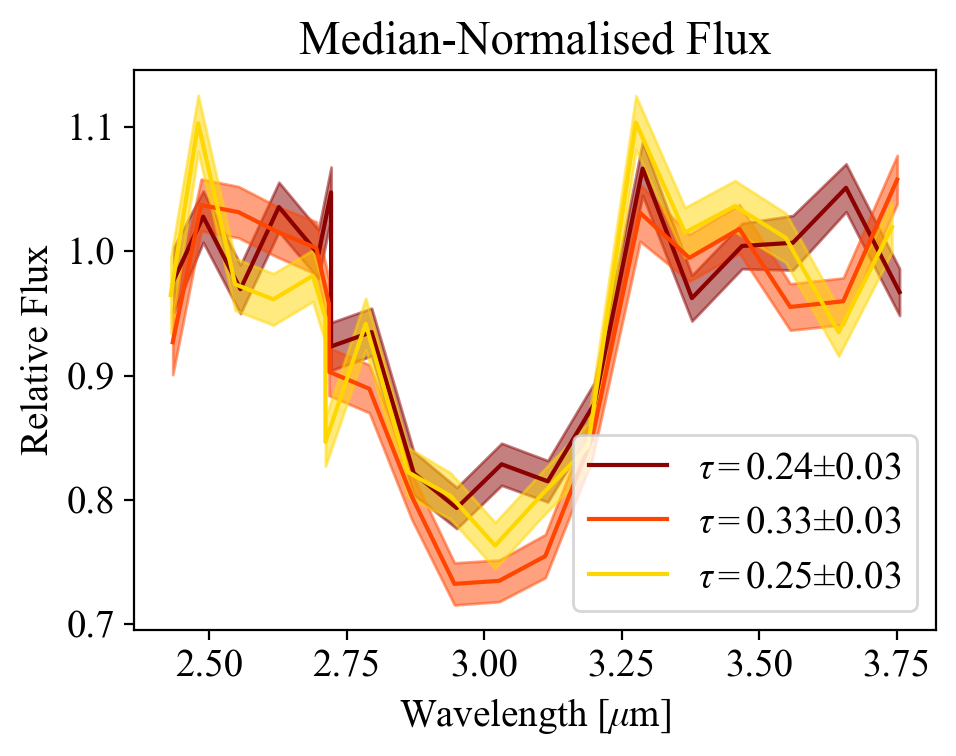

In [167]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
#f1[11] = np.nan
#f2[3] = np.nan
#f3[-6] = np.nan


collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/L1544-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

## L1512 - prestellar:

In [177]:
rlist = [76.0364167, 76.0454167, 76.0544167]   
dlist = [32.7211667, 32.7151667, 32.7051667]

#w1, f1, e1 = spectrum(rlist[0], dlist[0], 'L1512-SPHEREx', aper=False)
w2, f2, e2 = spectrum(rlist[1], dlist[1], 'L1512-SPHEREx', aper=False)
#w3, f3, e3 = spectrum(rlist[2], dlist[2], 'L1512-SPHEREx', aper=False)
#w4, f4 = spectrum(rlist[3], dlist[3], 'LDN183-SPHEREx', aper=False)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1058.5044364569042 5

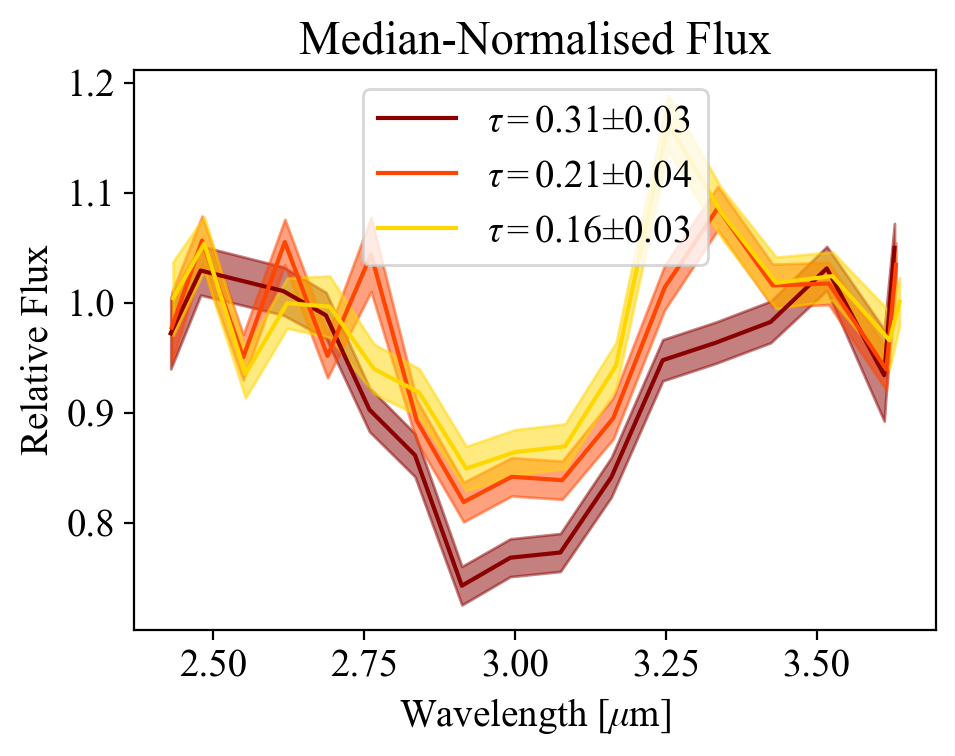

In [178]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
f1[2] = np.nan
#f2[3] = np.nan
#f3[-6] = np.nan


collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/L1512-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

## RCrA IRS 7B - bright YSO

In [209]:
rlist = [285.4102500, 285.4602500, 285.4502500, 285.4302500]
dlist = [-36.9602500, -36.9362500, -36.9362500, -36.9362500]

rlist = [285.4602500, 285.4802500, 285.5102500]
dlist = [-36.9362500, -36.9052500, -36.8852500]

#dlist = [-36.945, -36.945, -36.945, -36.945]
#w1, f1, e1 = spectrum(rlist[0], dlist[0], 'RCrA-SPHEREx')
#w2, f2, e2 = spectrum(rlist[1], dlist[1], 'RCrA-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'RCrA-SPHEREx')
#w4, f4, e4 = spectrum(rlist[3], dlist[3], 'RCrA-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
155.8703595263865 18

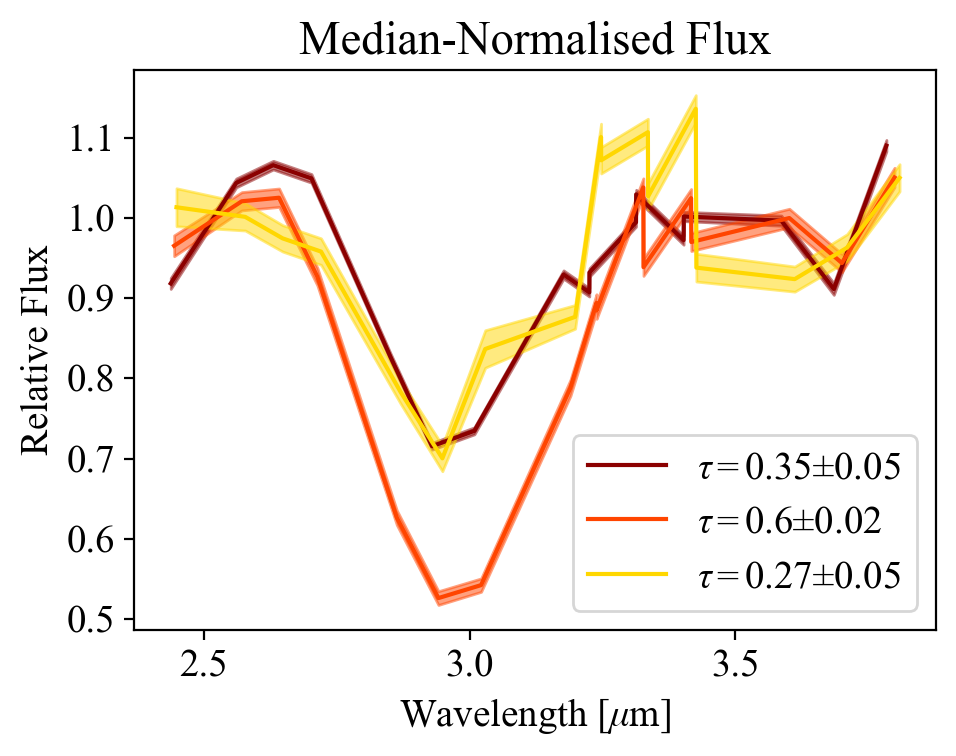

In [210]:
#f3[1] = np.nan

collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/R-CrA-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

## LDN 260 - prestellar:

In [188]:
rlist = [251.725, 251.7425000, 251.78, 251.78]   
dlist = [-9.62, -9.6055556, -9.595, -9.595]
rlist = [251.7885000, 251.799, 251.810]   
dlist = [-9.5835556, -9.578, -9.570]
w1, f1, e1 = spectrum(rlist[0], dlist[0], 'LDN260-SPHEREx')
w2, f2, e2 = spectrum(rlist[1], dlist[1], 'LDN260-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'LDN260-SPHEREx')


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
942.6095274791736 91

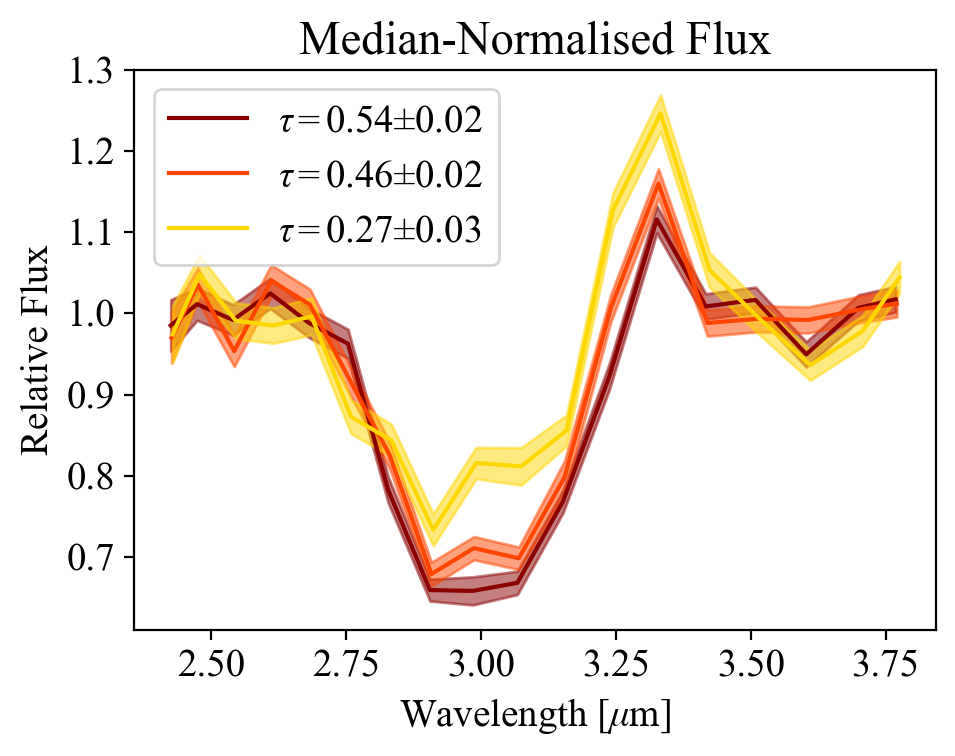

In [189]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
#f1[2] = np.nan
#f2[3] = np.nan
#f3[-6] = np.nan
f1[0] = f2[0] = f3[0] = np.nan

collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/L260-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

In [1423]:
f1/e1

array([ 171.99542,  387.19446,  976.62305, 1028.5131 , 1045.5842 ,
       1041.9741 ,  981.05695,  918.1543 ,  993.29346,  464.86633,
        750.05676,  959.9347 ,  912.5521 , 1081.9872 , 1070.8441 ,
       1065.0919 ,  988.73645,  902.15826, 1056.3855 ], dtype=float32)

## L1521 - faint YSO:

In [222]:
rlist = [67.1620833, 67.1660833, 67.1730833, ]
dlist = [26.8607222, 26.8547222, 26.8457222, ]

#w1, f1, e1 = spectrum(rlist[0], dlist[0], 'L1521-SPHEREx')
#w2, f2, e2 = spectrum(rlist[1], dlist[1], 'L1521-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'L1521-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1285.1605499361197 1

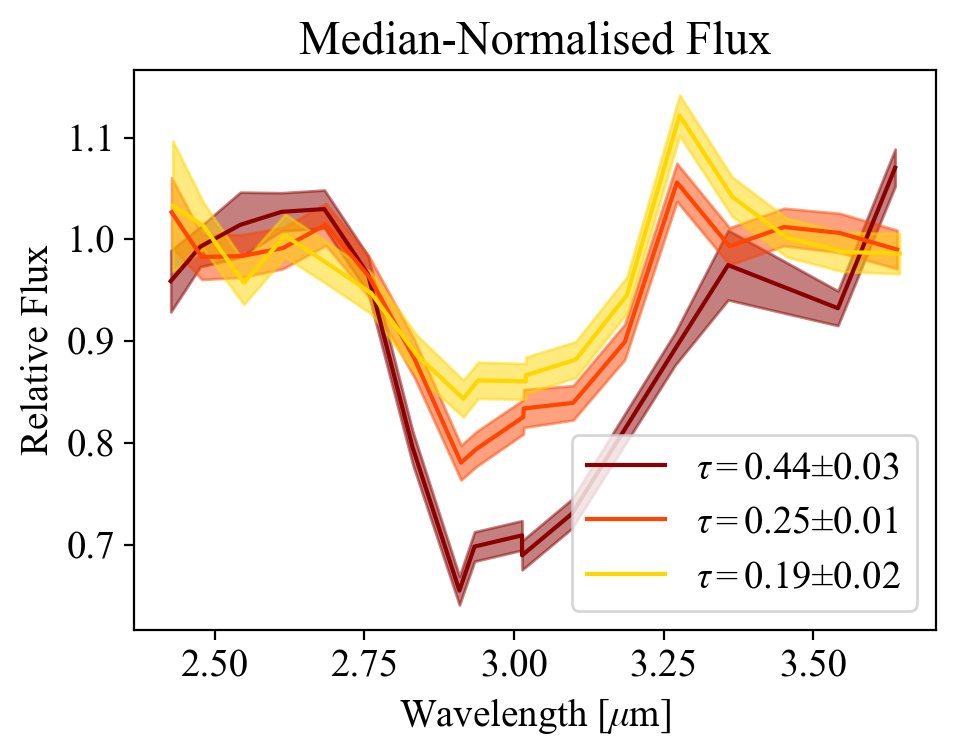

In [223]:

#f1[-3] = f1[-6] = np.nan

collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/L1521-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

## Ced 110 - moderate YSO:

In [217]:
rlist = [166.6906667, 166.7056667, 166.7206667, 166.7406667]   
dlist = [-77.3758333, -77.3728333, -77.3710333, -77.3643333]

#rlist = [166.7956667, 166.7956667, 166.7956667]   
#dlist = [-77.3960333, -77.3950333, -77.3900333]

#w1, f1, e1 = spectrum(rlist[0], dlist[0], 'Ced110-SPHEREx')
#w2, f2, e2 = spectrum(rlist[1], dlist[1], 'Ced110-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'Ced110-SPHEREx')
#w4, f4, e4 = spectrum(rlist[3], dlist[3], 'Ced110-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1410.9653830841023 7

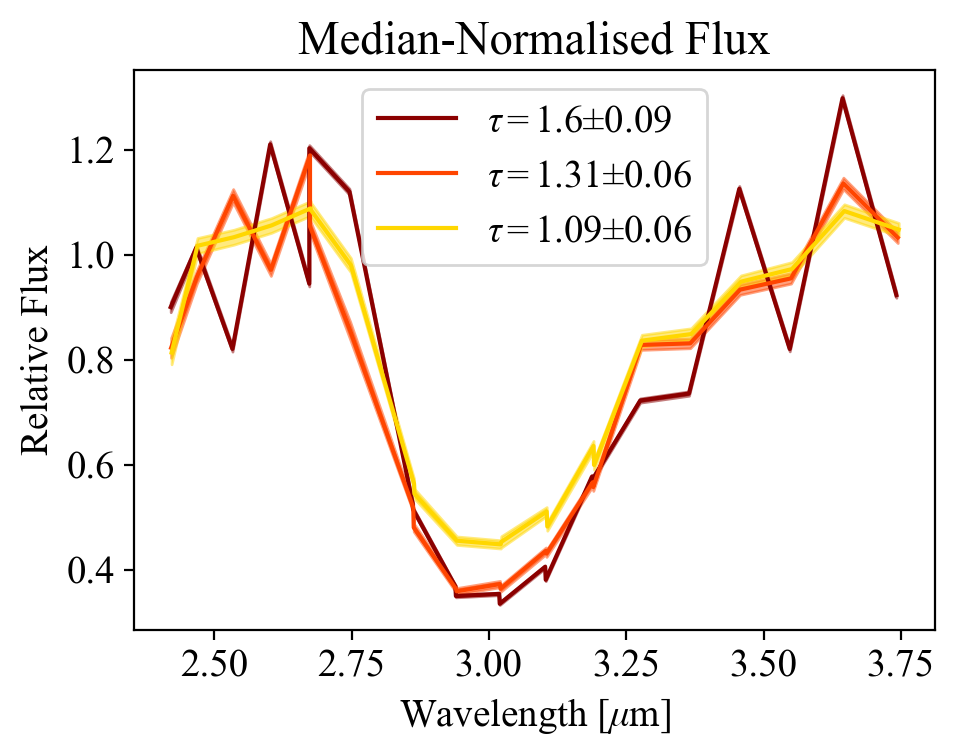

In [218]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
#f1[2] = np.nan
#f2[3] = np.nan
#f3[-6] = np.nan
#f1[0] = f2[0] = f3[0] = np.nan
f3[10] = np.nan
collist = ['darkred', 'orangered', 'gold']
plt.figure(figsize=(5,4), dpi=200)
for ww, ff, ee, cc in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3], collist):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    perr = np.sqrt(np.diag(pcov))
    cont = cont_fit(wv, *popt)
    y1 = (fv - cont)/np.nanmedian(fv[:6]) + 1
    y2 = (fv - ev - cont)/np.nanmedian(fv[:6]) + 1
    y3 = (fv + ev - cont)/np.nanmedian(fv[:6]) + 1
    mask = np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[mask] / cont[mask])
    J = np.empty((tau_all.size, popt.size))
    for i, idx in enumerate(np.where(((wv >= 2.9) & (wv <= 3.1)) & ~np.isnan(fv))[0]):
        eps = 1e-6
        for j in range(popt.size):
            dp = np.zeros_like(popt)
            dp[j] = eps
            cont_p = cont_fit(wv[idx], *(popt + dp))
            cont_m = cont_fit(wv[idx], *(popt - dp))
            dcont_dp = (cont_p - cont_m)/(2*eps)
            J[i, j] = (dcont_dp/cont[idx])
    tau_fit_var = np.einsum('ij,jk,ik->i', J, pcov, J)
    tau_data_var = (ev[~mask]/fv[~mask])**2
    tau_mean = np.nanmean(tau_all)
    N = tau_all.size
    tau_all_var = tau_fit_var + tau_data_var          
    tau_var_mean = np.nanmean(tau_all_var)            
    tau_err = np.sqrt(tau_var_mean / N)        

    
    plt.plot(wv, y1, marker='', color=cc, label=r'$\tau = $' + str(np.round(tau_mean, 2)) +
              r'$\pm$' + str(np.round(tau_err, 2)))
    plt.fill_between(wv, y2, y3, color=cc, alpha=0.5)


if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-6:]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[-6:]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[-6:]), marker='d', label='Outskirts')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel('Relative Flux')
plt.title('Median-Normalised Flux')
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/Ced110-threepoints.pdf', bbox_inches='tight', pad_inches=0)
#plt.ylim(0,1.5)

In [216]:
f3

array([0.52925146, 0.646476  , 0.63962007, 0.637267  , 0.6419316 ,
       0.6401598 ,        nan,        nan,        nan, 0.18787417,
       5.7717137 , 0.17222883, 0.17510147, 0.20241614, 0.1840032 ,
       0.2740536 , 0.25078866, 0.39581427, 0.39914215, 0.46037522,
       0.47515953, 0.5476493 , 0.52927774], dtype=float32)

# Visualisation

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


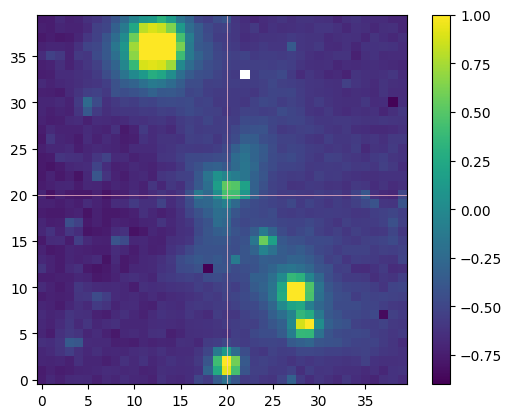

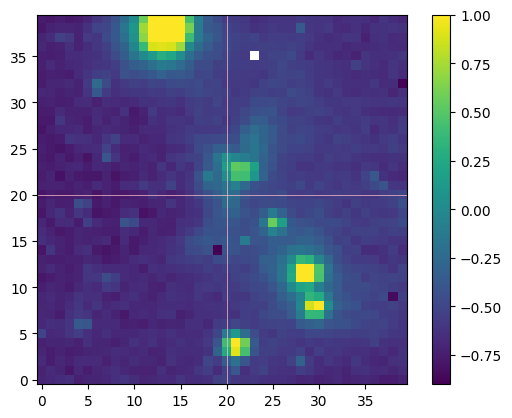

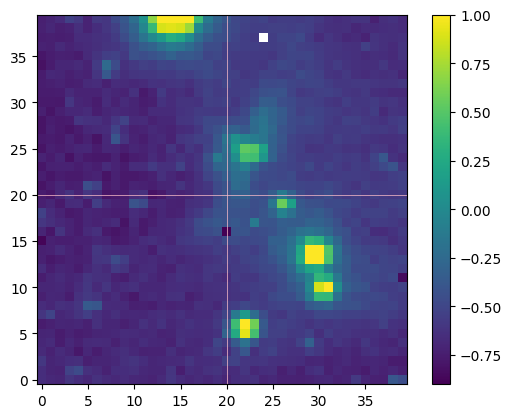

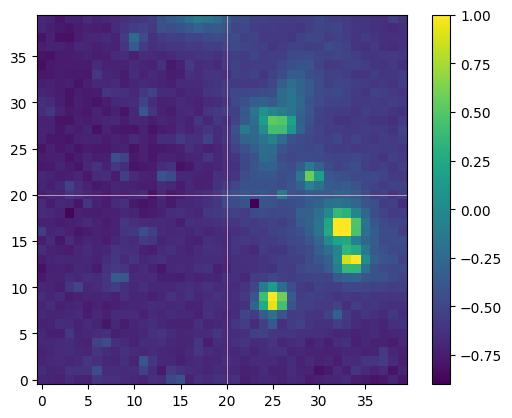

In [115]:
allfiles = glob.glob('L1521-SPHEREx/*.fits')
allfiles = glob.glob('Ced110-SPHEREx/*.fits')
#allfiles = glob.glob('CrA-151-SPHEREx/*.fits')

ww, ff = [], []

for a in allfiles[10:11]:
    hdulist = fits.open(a)
    img = hdulist[1].data
    wave = hdulist[6].data
    spectral_image_header = hdulist[1].header
    wcs = WCS(spectral_image_header)
    ra, dec = wcs.wcs.crval
    x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
    spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

    spectral_wcs.sip = None
    wl, bw = spectral_wcs.pixel_to_world(x, y)
    spectral_image = hdulist["IMAGE"]
    spectral_image_data = spectral_image.data
    (y, x) = np.indices(spectral_image.shape)
    spectral_coords = spectral_wcs.pixel_to_world(x, y)
    wavelength, bandwidth = spectral_coords

    coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
    #coord = SkyCoord(ra=294.2559167*u.deg, dec=7.5698889*u.deg, frame="icrs")
    #coord = SkyCoord(ra=53.3245*u.deg, dec=31.1589*u.deg, frame="icrs")
    #285.4852500 -36.9582500
    rlist = [67.1620833, 67.1680833, 67.1570833]
    dlist = [26.8664222, 26.8707222, 26.8587222]
    rlist = [67.1620833, 67.1660833, 67.1560833, 67.1720833]
    dlist = [26.8664222, 26.8547222, 26.8567222, 26.8767222]
    rlist = [285.4102500, 285.4602500, 285.4502500, 285.4302500]
    dlist = [-36.9602500, -36.9362500, -36.9362500, -36.9362500]
    rlist = [76.0697917, 76.0857917, 76.0997917]
    dlist = [25.18125, 25.17025, 25.14225]
    rlist = [76.0324167, 76.0434167, 76.0544167]   
    dlist = [32.7311667, 32.7301667, 32.7281667]
    rlist = [76.0697917, 76.0857917, 76.0997917]
    dlist = [25.18125, 25.17025, 25.14225]
    rlist = [166.6906667, 166.7056667, 166.7206667, 166.7406667]   
    dlist = [-77.3758333, -77.3728333, -77.3710333, -77.3643333]
    for rr,dd in zip(rlist,dlist):
        coord = SkyCoord(ra=rr*u.deg, dec=dd*u.deg, frame="icrs")
        #294.2529167    7.5688889
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        flux = img[int(y+0.5),p1:p2]
        lam = wavelength.value[int(y+0.5),p1:p2]
        sm = 2
        flux = ndimage.gaussian_filter1d(flux, sm)
        ww.append(np.mean(lam))
        ff.append(flux)
    
        x1, x2 = int(x-20), int(x+20)
        y1, y2 = int(y-20), int(y+20)
        arr = img.copy()[y1:y2, x1:x2]
        plt.imshow(np.log10(arr), vmin=-0.9, vmax=1, origin='lower')
        #plt.imshow(np.array(arr), vmin=0., vmax=0.55, origin='lower')
        plt.colorbar()
        
        plt.axvline(20, color='pink', lw=0.5)
        plt.axhline(20, color='pink', lw=0.5)
        plt.show()

## Old Code:

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


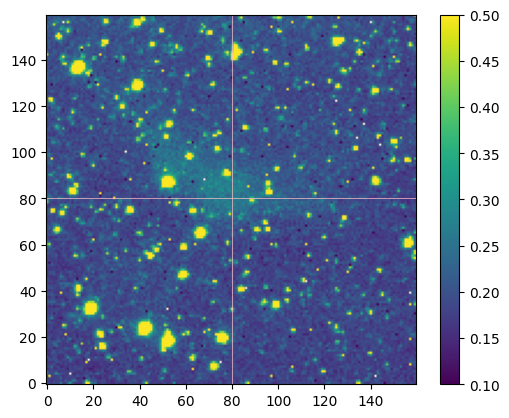

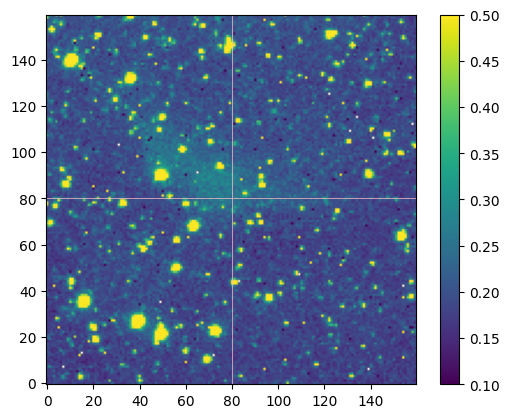

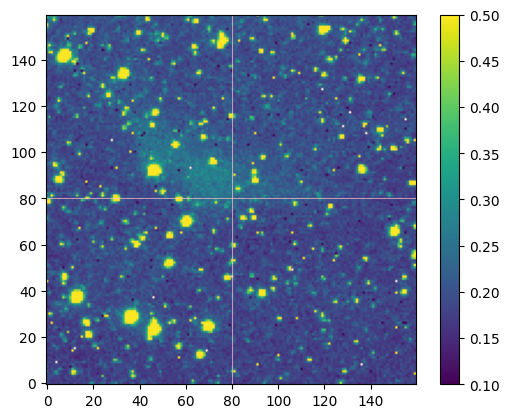

In [1008]:
allfiles = glob.glob('LDN260-SPHEREx/*.fits')
#allfiles = glob.glob('RCrA-SPHEREx/*.fits')
#allfiles = glob.glob('CrA-151-SPHEREx/*.fits')

ww, ff = [], []

for a in allfiles[5:6]:
    hdulist = fits.open(a)
    img = hdulist[1].data
    wave = hdulist[6].data
    spectral_image_header = hdulist[1].header
    wcs = WCS(spectral_image_header)
    ra, dec = wcs.wcs.crval
    x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
    spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

    spectral_wcs.sip = None
    wl, bw = spectral_wcs.pixel_to_world(x, y)
    spectral_image = hdulist["IMAGE"]
    spectral_image_data = spectral_image.data
    (y, x) = np.indices(spectral_image.shape)
    spectral_coords = spectral_wcs.pixel_to_world(x, y)
    wavelength, bandwidth = spectral_coords

    coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
    #coord = SkyCoord(ra=294.2559167*u.deg, dec=7.5698889*u.deg, frame="icrs")
    #coord = SkyCoord(ra=53.3245*u.deg, dec=31.1589*u.deg, frame="icrs")
    #285.4852500 -36.9582500
    rlist = [238.5408333,238.5458333,238.5478333]   
    dlist = [-2.8263333,-2.8103333,-2.803333]
    rlist = [238.5408333,238.5328333,238.5198333]   
    dlist = [-2.8263333,-2.8263333,-2.8233333]
    rlist = [76.0617917, 76.0537917, 76.0237917]
    dlist = [25.18725, 25.20725, 25.23525]
    rlist = [251.7925000, 251.799, 251.805]   
    dlist = [-9.5835556, -9.578, -9.575]
    for rr,dd in zip(rlist,dlist):
        coord = SkyCoord(ra=rr*u.deg, dec=dd*u.deg, frame="icrs")
        #294.2529167    7.5688889
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        flux = img[int(y+0.5),p1:p2]
        lam = wavelength.value[int(y+0.5),p1:p2]
        sm = 2
        flux = ndimage.gaussian_filter1d(flux, sm)
        ww.append(np.mean(lam))
        ff.append(flux)
    
        x1, x2 = int(x-80), int(x+80)
        y1, y2 = int(y-80), int(y+80)
        arr = img.copy()[y1:y2, x1:x2]
        #plt.imshow(np.log10(arr), vmin=-0.7, vmax=-0.3, origin='lower')
        plt.imshow(np.array(arr), vmin=0.1, vmax=0.5, origin='lower')
        plt.colorbar()
        
        plt.axvline(80, color='pink', lw=0.5)
        plt.axhline(80, color='pink', lw=0.5)
        plt.show()

In [769]:
rlist, dlist

([76.0617917, 76.0477917, 76.0337917],
 [25.18725, 25.201249999999998, 25.215249999999997])

In [427]:
ff = np.array(ff)
ff = ff[np.argsort(ww),:]
ww = np.sort(ww)

s1, s2 =30,31
ff[10,:] = (ff[9,:]+ff[11,:]) / 2
#ff[10,:] = np.nan
s=1

c1, c2, c3 = 71,81,90
for ind, lbl in zip([c1, c2, c3], ['left edge', 'centre', 'right edge']):
    frac = (ind-s1) / (s2-s1)
    r, g, b = frac, 0, 1-frac
    #plt.plot(ww, ff[:,ind]/np.nanmedian(ff[7:13,ind]), label=lbl, marker='d')
    plt.plot(ww, ff[:,ind]/np.nanmedian(ff[:4,ind]), label=lbl, marker='d')
#plt.axvline(ww[10], color='k')
plt.xlabel('Wavelength um')
plt.ylabel('Normalised flux')
#plt.ylim(0,2)
plt.legend()
plt.show()


x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()[y1:y2, x1:x2]
plt.imshow(arr, vmin=0, vmax=1., origin='upper')
plt.colorbar()

[plt.axvline(a, color='pink') for a in [c1, c2, c3]]
plt.axhline(80, color='pink')
plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 4

## Compare with ice absorption in known starless and protostellar cores and see which matches 

## -- bigger idea: look at ice absorption patterns in multiple cores of each type and try to find differentiating factor

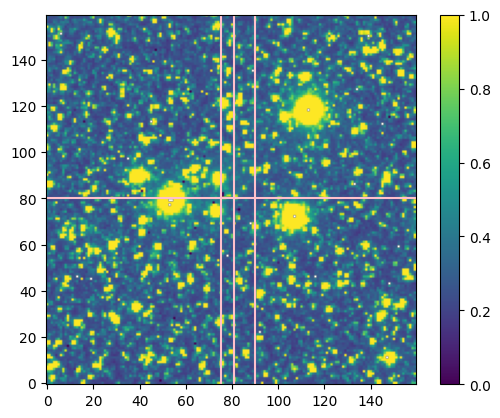

In [104]:
x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()[y1:y2, x1:x2]
plt.imshow(arr, vmin=0, vmax=1., origin='lower')
plt.colorbar()

[plt.axvline(a, color='pink') for a in [75,81,90]]
plt.axhline(80, color='pink')

# Integrate Flux:

## Older codes:

In [495]:
quad(pathlength, 0, 0.01, args=(10,0.01,1))

(0.0009901478633121998, 1.0992849556326065e-17)

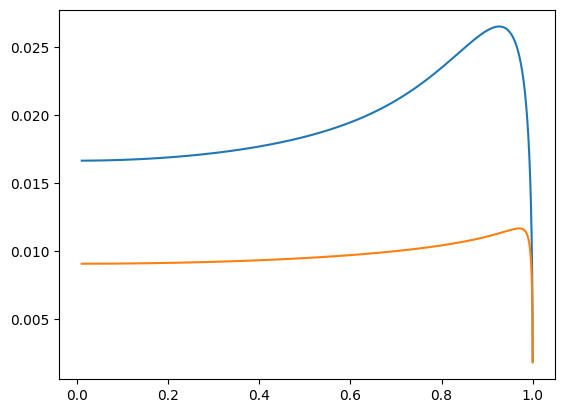

In [721]:
from scipy.integrate import quad

def pathlength_los(u, R, x, R0):
    r = R*np.cos(x)/np.cos(u)
    rho_R = R0**2 / (r**2 + R0**2)
    dl = r / np.cos(u)
    r_evap = R0 * 1
    width = R0 * 0.1
    #ice_abs = 0.75 + 0.25*np.tanh((r - r_evap) / width)
    return rho_R * dl

def pathlength_central(u, R0):
    rho_R = R0**2 / (u**2 + R0**2)
    return rho_R

g = 0.0

def f(t, x, R, R0, tau_h2o, tau_cont, ext_fact):
    r = R*np.cos(x)/np.cos(t)
    pcen = quad(pathlength_central, 0, r, args=(R0,))[0]
    lum_R = np.exp(-tau_cont*pcen) / r**2 + ext_fact * np.exp(-tau_cont * (ptot-pcen))
    angle_factor = (1-g**2) / (1 + g**2 - 2*g*np.sin(t))**1.5
    rho_R = R0**2 / (r**2 + R0**2)
    dV = r / np.cos(t)
    plos = R * (np.sin(x) + np.sin(t))
    plos = quad(pathlength_los, t, x, args=(R, x, R0))[0]
    absorption = np.exp(-(tau_h2o + tau_cont)*plos)
    return lum_R * rho_R * angle_factor * dV * absorption

R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 50, 30, 1

#R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 5, 1, 1
ptot = quad(pathlength_central, 0, R, args=(R0,))[0]

def continuum(t, x):
    return f(t, x, R=R, R0=R0, tau_h2o=0, tau_cont=tau_cont, ext_fact = ext_fact)

def ice(t, x):
    return f(t, x, R=R, R0=R0, tau_h2o=tau_h2o, tau_cont=tau_cont, ext_fact = ext_fact)

x = np.linspace(0.01,1.56,1000)
cc = np.array([quad(continuum, -xl, xl, args=(xl,))[0] for xl in x])
hh = np.array([quad(ice, -xl, xl, args=(xl,))[0] for xl in x])
plt.plot(np.cos(x), cc, marker='')
plt.plot(np.cos(x), hh, marker='')
#plt.yscale('log')

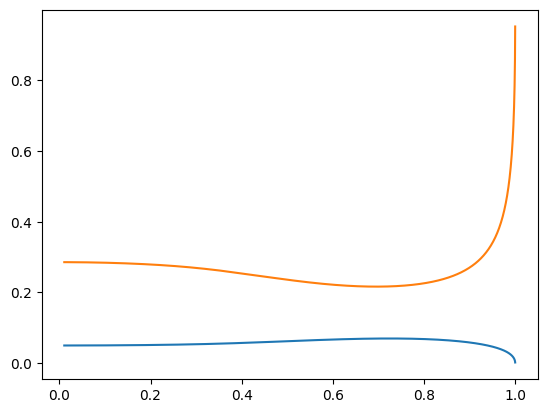

In [720]:
plt.plot(np.cos(x), cc, marker='')
plt.plot(np.cos(x), hh/cc, marker='')
#plt.yscale('log')

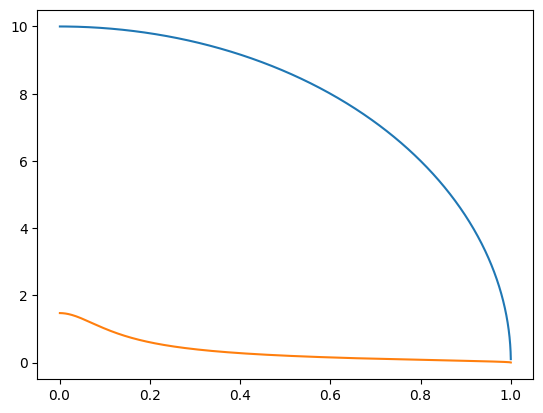

In [598]:
t = 0.
plos1 = [R * (np.sin(x) + np.sin(t)) for x in np.linspace(0.01,1.57,1000)]
plos2 = [quad(pathlength_los, t, x, args=(R, x, R0))[0] for x in np.linspace(0.01,1.57,1000)]
xr = np.linspace(0.01,1.57,1000)
plt.plot(np.cos(xr), plos1)
plt.plot(np.cos(xr), plos2)

## YSO Illuminated Core:

/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/4265588272.py:64: RuntimeWarning: invalid value encountered in divide
  ratio = I_ice / I_cont


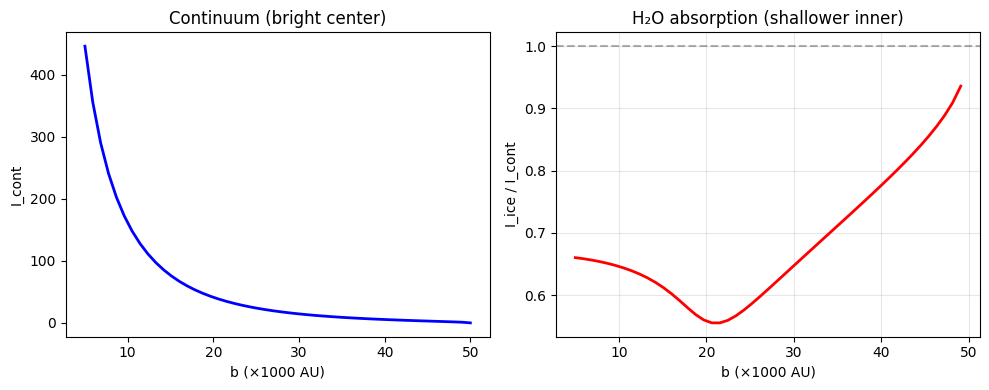

In [1228]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

R_cloud = 0.05
R0      = 0.02
tau_cont0 = 2e-3 * 1e3
tau_ice0  = 50e-3 * 1e3

# Ice depletion parameters
r_warm = 0.02  # pc, inner warm region
width  = 0.003  # pc, transition width

def rho(r, R0=R0):
    return R0**2 / (r**2 + R0**2)

def ice_factor(r):
    """Ice abundance: depleted inside r_warm, full outside."""
    return 0.5 * (1 + np.tanh((r - r_warm)/width))

def tau_radial(r, tau_cont):
    if r <= 0:
        return 0.0
    return tau_cont * quad(lambda rp: rho(rp), 0, r)[0]

def tau_los(b, s, tau_cont, tau_ice):
    s_max = np.sqrt(max(R_cloud**2 - b**2, 0))
    if s >= s_max:
        return 0.0
    def integrand(sp):
        r = np.sqrt(b**2 + sp**2)
        return rho(r) * (tau_cont + tau_ice * ice_factor(r))  # ← ice gradient
    return quad(integrand, s, s_max)[0]

def emissivity(r, tau_cont):
    if r == 0:
        return 0.0
    J_r = np.exp(-tau_radial(r, tau_cont)) / r**2
    return rho(r) * J_r

def intensity_continuum(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, 0)
        return j * np.exp(-tau_l)
    return quad(integrand, -s_max, s_max)[0]

def intensity_ice(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, tau_ice0)
        return j * np.exp(-tau_l)
    return quad(integrand, -s_max, s_max)[0]

b_vals = np.linspace(0.005, R_cloud, 50)
I_cont = np.array([intensity_continuum(b) for b in b_vals])
I_ice  = np.array([intensity_ice(b)     for b in b_vals])
ratio = I_ice / I_cont

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.plot(b_vals*1000, I_cont, 'b-', lw=2)
ax1.set_xlabel("b (×1000 AU)")
ax1.set_ylabel("I_cont")
ax1.set_title("Continuum (bright center)")

ax2.plot(b_vals*1000, ratio, 'r-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.3)
ax2.set_xlabel("b (×1000 AU)")
ax2.set_ylabel("I_ice / I_cont")
ax2.set_title("H₂O absorption (shallower inner)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Scattering/coreshine illuminated core:

In [226]:
rho0 * kappa_abs * r0

0.65

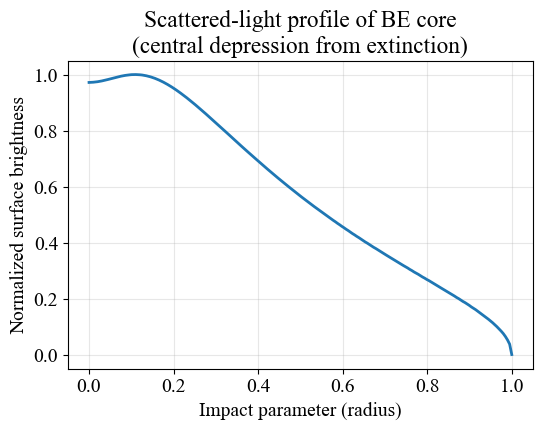

In [224]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Grid and geometry
# -----------------------------
R_max = 1.0          # core radius (arbitrary units)
nr = 500
ns = 800

r = np.linspace(0, R_max, nr)
b_vals = np.linspace(0, R_max, 200)

# Line-of-sight coordinate
s = np.linspace(-R_max, R_max, ns)

# -----------------------------
# Bonnor–Ebert–like density profile
# (analytic approximation)
# -----------------------------
rho0 = 1.0
r0 = 0.1             # flat inner radius
rho = rho0 / (1 + (r / r0)**2)
rhosat = rho0

# Interpolation helper
def rho_interp(x):
    return np.interp(x, r, rho, left=0, right=0)

# -----------------------------
# Dust properties
# -----------------------------
kappa_abs = 6.5      # absorption opacity
kappa_sca = 1.5      # scattering opacity
kappa_ext = kappa_abs + kappa_sca
albedo = kappa_sca / kappa_ext

# -----------------------------
# Optical depth integrals
# -----------------------------
def tau_along_path(r_vals):
    """Cumulative optical depth along LOS"""
    return np.cumsum(rho_interp(r_vals)) * kappa_ext * (2 * R_max / ns)

# -----------------------------
# Surface brightness
# -----------------------------
I = []

for b in b_vals:
    r_los = np.sqrt(b**2 + s**2)
    inside = r_los <= R_max

    r_use = r_los[inside]
    s_use = s[inside]

    # Optical depth from surface -> scattering point
    tau_in = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[:i+1]**2)
        rhor = rho_interp(path)
        #tau_in[i] = np.trapz(rhor, s_use[:i+1]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+rhor/rhosat) + albedo)
        tau_in[i] = np.trapz(rhoeff, s_use[:i+1]) * kappa_ext

    # Optical depth from scattering point -> observer
    tau_out = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[i:]**2)
        rhor = rho_interp(path)
        #tau_out[i] = np.trapz(rhor, s_use[i:]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+rhor/rhosat) + albedo)
        tau_out[i] = np.trapz(rhoeff, s_use[i:]) * kappa_ext

    # Incident radiation field
    J_inc = np.exp(-tau_in)

    # Scattered emissivity
    emissivity = rho_interp(r_use) * kappa_sca * J_inc

    # Attenuation after scattering
    contrib = emissivity * np.exp(-tau_out)

    I.append(np.trapz(contrib, s_use))

I = np.array(I)
I_ice = I.copy()

# Normalize
I /= I.max()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(b_vals, I, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
plt.grid(alpha=0.3)
plt.show()


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/1921418096.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(b_vals, I_ice/I_cont, lw=2)


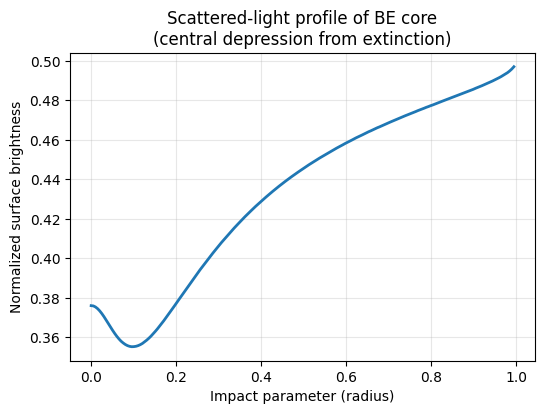

In [1278]:
plt.figure(figsize=(6,4))
plt.plot(b_vals, I_ice/I_cont, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
plt.grid(alpha=0.3)
plt.show()


## Older codes:

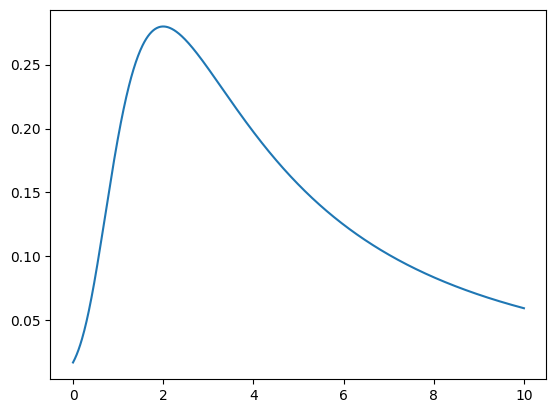

In [624]:
ptot = quad(pathlength_central, 0, R, args=(R0,))[0]
pcen = np.array([quad(pathlength_central, 0, r, args=(R0,))[0] for r in np.linspace(0,R,1000)])

R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 50, 4, 6
rho_R = np.array([R0**2 / (r**2 + R0**2) for r in np.linspace(0,R,1000)])
lum_R = np.exp(-tau_cont*pcen) / r**2 + ext_fact * np.exp(-tau_cont * (ptot-pcen))

plt.plot(np.linspace(0,R,1000), lum_R*rho_R)

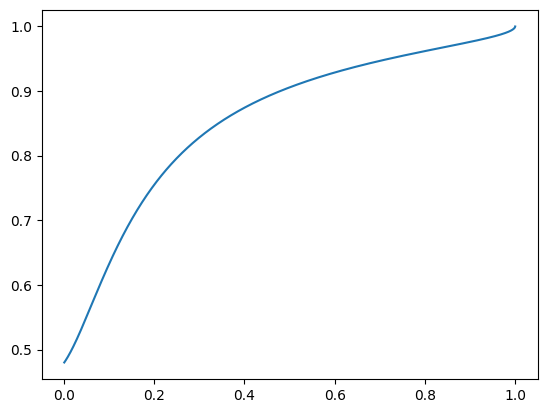

In [602]:
plt.plot(np.cos(x), hh/cc, marker='')
#plt.yscale('log')

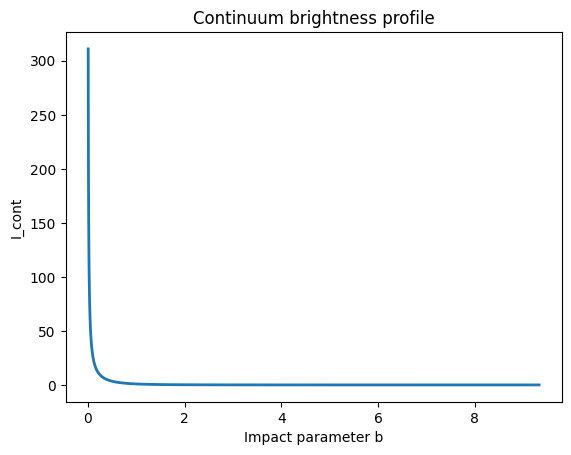

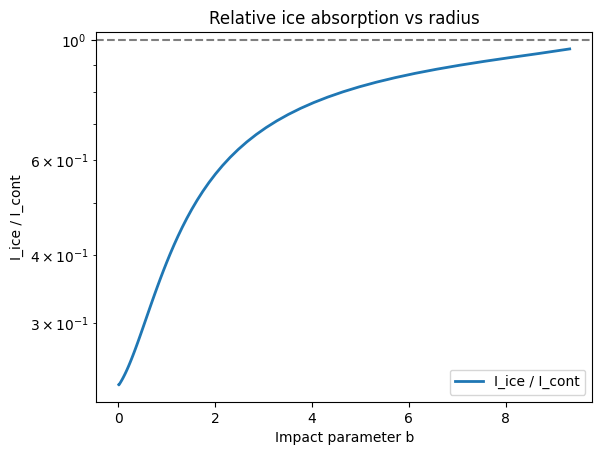

In [542]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Global parameters (you can tune these)
R   = 10.0   # outer radius (arbitrary units)
R0  = 1.0    # density scale radius
r_evap = R0/100.0
width  = R0/1000.0

# ------------------------------
# Basic radial profiles
# ------------------------------

def rho(r, R0=R0):
    """Spherical density profile rho(r) = R0^2 / (r^2 + R0^2)."""
    return R0**2 / (r**2 + R0**2)

def ice_factor(r):
    """0 inside r_evap, ~1 outside, smoothed with tanh."""
    return 0.5 * (1.0 + np.tanh((r - r_evap)/width))

# ------------------------------
# Optical depths
# ------------------------------

def tau_radial(r, tau_cont):
    """
    Radial continuum optical depth from center to radius r.
    tau_cont is an overall scaling factor (per unit 'rho' * dr).
    """
    if r <= 0:
        return 0.0
    integrand = lambda rp: rho(rp)
    tau = tau_cont * quad(integrand, 0.0, r, epsabs=1e-5, epsrel=1e-4)[0]
    return tau

def tau_los(b, s, tau_cont, tau_h2o):
    """
    LOS optical depth from position (b,s) to the near side (s -> +sqrt(R^2 - b^2)).
    b: impact parameter, s: current LOS position (negative behind, positive front).
    """
    s_max = np.sqrt(max(R**2 - b**2, 0.0))
    if s >= s_max:
        return 0.0

    def integrand(sp):
        r = np.sqrt(b**2 + sp**2)
        return rho(r) * (tau_cont + tau_h2o * ice_factor(r))

    tau = quad(integrand, s, s_max, epsabs=1e-5, epsrel=1e-4)[0]
    return tau

# ------------------------------
# Local emissivity from central source
# ------------------------------

def emissivity(r, tau_cont):
    """
    Local emissivity j(r) ∝ rho(r) * J(r),
    where J(r) ∝ exp(-tau_radial) / r^2 is the attenuated central intensity.
    """
    if r == 0:
        return 0.0
    J_r = np.exp(-tau_radial(r, tau_cont)) / r**2
    return rho(r) * J_r

# ------------------------------
# Specific intensity at impact parameter b
# ------------------------------

def intensity(b, tau_h2o, tau_cont):
    """
    Compute I(b) by integrating along the line of sight through the envelope.
    b: impact parameter (0 = center, up to R).
    """
    if b >= R:
        return 0.0

    # s ranges from -s_max (far side) to +s_max (near side)
    s_max = np.sqrt(R**2 - b**2)

    def integrand(s):
        r = np.sqrt(b**2 + s**2)
        j_r = emissivity(r, tau_cont)
        # attenuation from this point to the observer
        tau_l = tau_los(b, s, tau_cont, tau_h2o)
        return j_r * np.exp(-tau_l)

    I, _ = quad(integrand, -s_max, s_max, epsabs=1e-5, epsrel=1e-4)
    return I

# ------------------------------
# Convenience wrappers for continuum vs ice
# ------------------------------

def continuum_intensity(b):
    # very small continuum opacity to keep envelope optically thin-ish
    return intensity(b, tau_h2o=0.0, tau_cont=1e-4)

def ice_intensity(b):
    return intensity(b, tau_h2o=1.0, tau_cont=1e-4)

# ------------------------------
# Example: center-to-edge profile
# ------------------------------

# impact parameter grid from center (0) to edge (R)
b_vals = np.logspace(-2, np.log10(R), 100)

I_cont = np.array([continuum_intensity(b) for b in b_vals])
I_ice  = np.array([ice_intensity(b) for b in b_vals])

# avoid division by zero; restrict to inside envelope
mask = I_cont > 0
b_plot  = b_vals[mask]
ratio   = I_ice[mask] / I_cont[mask]

plt.figure()
plt.plot(b_plot, I_cont[mask], label="Continuum", lw=2)
plt.xlabel("Impact parameter b")
plt.ylabel("I_cont")
plt.title("Continuum brightness profile")

plt.figure()
plt.plot(b_plot, ratio, label="I_ice / I_cont", lw=2)
plt.xlabel("Impact parameter b")
plt.ylabel("I_ice / I_cont")
plt.yscale('log')
plt.title("Relative ice absorption vs radius")
plt.axhline(1.0, color='k', ls='--', alpha=0.5)
plt.legend()
plt.show()
